In [1]:
import pydot
import matplotlib.pyplot as plt
from collections import deque

In [ ]:

def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}
    
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph
    
    return adjacency_list

dot_file = "../Dataset/Step1/LesMiserables.dot"
graph = parse_dot_file(dot_file)
root_node = "1"

def bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)
        
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree

def dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}
    
    visited.add(root)
    
    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            dfs_tree(graph, neighbor, visited, tree)
    
    return tree

def draw_layered_tree(tree, title="Layered Tree Layout"):
    levels = {}
    def assign_levels(node, depth=0):
        if node not in levels:
            levels[node] = depth
        for child in tree[node]:
            assign_levels(child, depth + 1)
    assign_levels(next(iter(tree)))
    
    nodes_by_level = {}
    for node, level in levels.items():
        if level not in nodes_by_level:
            nodes_by_level[level] = []
        nodes_by_level[level].append(node)
    
    plt.figure(figsize=(8, 6))
    y_positions = {level: -level for level in nodes_by_level}
    x_positions = {}
    
    for level in nodes_by_level:
        x_spacing = 2
        start_x = -x_spacing * (len(nodes_by_level[level]) - 1) / 2
        for i, node in enumerate(nodes_by_level[level]):
            x_positions[node] = (start_x + i * x_spacing, y_positions[level])
    
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent]
            x2, y2 = x_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-')
    
    for node, (x, y) in x_positions.items():
        plt.text(x, y, node, ha='center', va='center', fontsize=12,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    
    plt.title(title)
    plt.axis('off')
    plt.show()


bfs_result = bfs_tree(graph, root_node)
dfs_result = dfs_tree(graph, root_node)


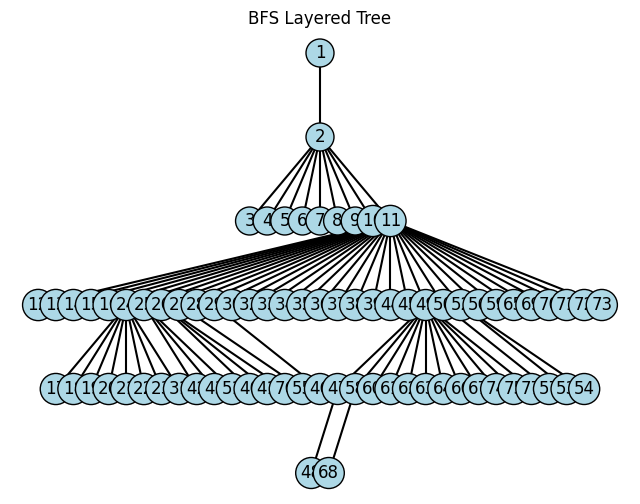

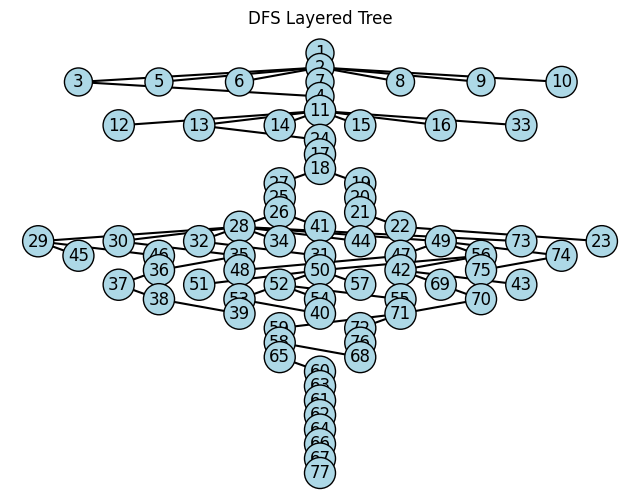

In [4]:
draw_layered_tree(bfs_result, "BFS Layered Tree")
draw_layered_tree(dfs_result, "DFS Layered Tree")